In [1]:
import pandas as pd

In [2]:
weather_2012 = pd.read_csv('../data/weather_2012.csv', parse_dates=True, index_col='Date/Time', dtype='unicode')

In [3]:
berri_bikes = pd.read_csv('../data/bikes.csv', sep=';', encoding='latin1', parse_dates=['Date'], dayfirst=True, index_col='Date')

In [4]:
berri_bikes = berri_bikes[['Berri 1']].resample('D').sum()
berri_bikes[:5]

,Berri 1
Date,
2012-01-01,35
2012-01-02,83
2012-01-03,135
2012-01-04,144
2012-01-05,197


In [6]:
# 把一天24小時的溫度取平均
weather_daily = weather_2012[['Temp (C)']].astype(float).resample('D').mean()
weather_daily[:5]

,Temp (C)
Date/Time,
2012-01-01,0.629167
2012-01-02,0.041667
2012-01-03,-14.416667
2012-01-04,-13.645833
2012-01-05,-6.750000


In [7]:
merged = pd.merge(berri_bikes, weather_daily, left_index=True, right_index=True)
merged[:5]

,Berri 1,Temp (C)
Date,,
2012-01-01,35,0.629167
2012-01-02,83,0.041667
2012-01-03,135,-14.416667
2012-01-04,144,-13.645833
2012-01-05,197,-6.750000


<Axes: xlabel='Temp (C)', ylabel='Berri 1'>

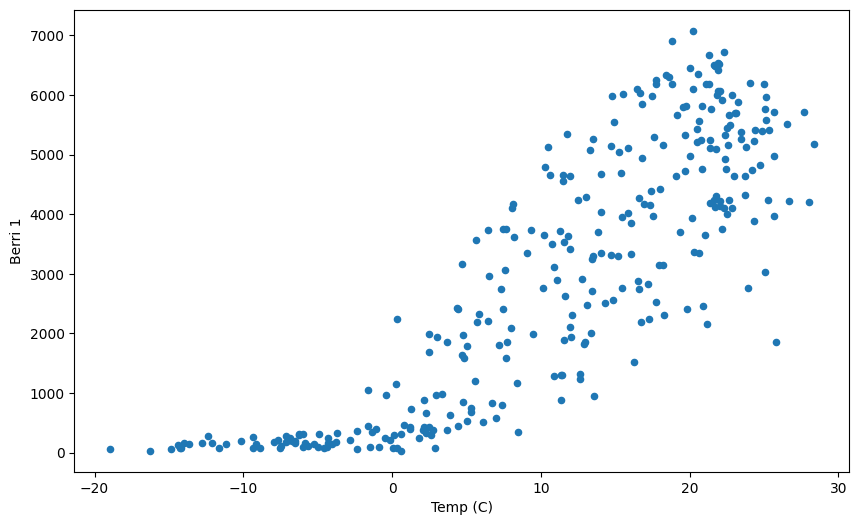

In [9]:
merged.plot(kind='scatter', x='Temp (C)', y='Berri 1', figsize=(10, 6))